In [14]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LinearRegression
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
import glob
from sklearn.model_selection import LeaveOneOut


# Define space arrays
lats = np.arange(-88.75, 88.751, 2.5)
lons = np.arange(1.25, 358.751, 2.5)

# Define time arrays
decades = np.arange(1950, 2023, 1)/10
years = decades * 10

# Plots
linestyles = ['-', '--', ':', '-.']
month_labels = ['March', 'April', 'May']

# Dynamic Adjustment with My Observations - K-Fold Cross Validation

## Functions

In [9]:
def spatial_average_3(array, lats):
    weights = np.cos(np.deg2rad(lats))
    weights_array = weights[np.newaxis, :, np.newaxis]
    weighted_array = np.multiply(array, weights_array)
    s = np.shape(weighted_array)
    weighted_reshaped = np.reshape(weighted_array, (s[0], s[1]*s[2]))
    weighted_sum = np.nansum(weighted_reshaped, axis=1)
    denom = np.nansum(weights) * 144
    return np.divide(weighted_sum, denom)


def spatial_average_4(array, lats):
    weights = np.cos(np.deg2rad(lats))
    weights_array = weights[np.newaxis, np.newaxis, :, np.newaxis]
    weighted_array = np.multiply(array, weights_array)
    s = np.shape(weighted_array)
    weighted_reshaped = np.reshape(weighted_array, (s[0], s[1], s[2]*s[3]))
    weighted_sum = np.nansum(weighted_reshaped, axis=2)
    denom = np.nansum(weights) * 144
    return np.divide(weighted_sum, denom)


def spatial_average_5(array, lats):
    weights = np.cos(np.deg2rad(lats))
    weights_array = weights[np.newaxis, np.newaxis, np.newaxis, :, np.newaxis]
    weighted_array = np.multiply(array, weights_array)
    s = np.shape(weighted_array)
    weighted_reshaped = np.reshape(weighted_array, (s[0], s[1], s[2], s[3]*s[4]))
    weighted_sum = np.nansum(weighted_reshaped, axis=3)
    denom = np.nansum(weights) * 144
    return np.divide(weighted_sum, denom)


def dynamic_adjustment(X, Y, weights):
    # Detrend Y timeseries
    Y_regression = stats.linregress(decades, Y)
    Y_regression = Y_regression[1] + Y_regression[0] * decades
    Y_detrended = Y - Y_regression

    # Comment out to detrend
    # Y_detrended = Y

    # Standardize (de)trended data
    Xs = X / np.std(X, axis=0)
    Ys = Y_detrended / np.std(Y_detrended)

    # Find correlation-coefficient map (CC)
    CC = []
    for lat in range(np.shape(Xs)[1]):
        lat_line = []
        for lon in range(np.shape(Xs)[2]):
            Xs_ts = Xs[:, lat, lon]
            corr = stats.pearsonr(Xs_ts, Ys)[0]
            lat_line.append(corr)
        CC.append(lat_line)

    # Weight CC by area and normalize
    CC_weighted = np.multiply(CC, weights[:, np.newaxis])
    CC_weighted_1d = CC_weighted.ravel()
    CC_normed = CC_weighted_1d / np.sqrt(np.dot(CC_weighted_1d, CC_weighted_1d))
    CC_weighted_normed = np.reshape(CC_normed, np.shape(CC_weighted))

    # Project standardized predictor SLP field X onto weighted CC
    Z = np.array([np.dot(CC_weighted_normed.ravel(), Xs[i].ravel()) for i in range(0, len(X))])
    Z_normed = Z / np.sqrt(np.dot(Z, Z))

    # Regress Z out of X
    X_features = np.reshape(X, (len(X), np.shape(X)[1]*np.shape(X)[2]))
    P = np.matmul(X_features.T, Z_normed)
    X_regressed_out_Z = X_features - np.matmul(Z_normed.reshape(-1, 1), P.T.reshape(1, -1))
    X_regressed_out_Z = X_regressed_out_Z.reshape(np.shape(X))

    # Regress Z out of Y
    beta = np.matmul(Z_normed.T, Y)
    Y_regressed_out_Z = Y - beta * Z_normed

    return X_regressed_out_Z, Y_regressed_out_Z, Z_normed, CC


def reg_finder(X, z):
    regr_map, recr_map = [], []
    for lat in range(np.shape(X)[1]):
        regr_by_lat, recr_by_lat = [], []
        for lon in range(np.shape(X)[2]):
            X_ts = X[:, lat, lon]
            try:
                regr = stats.linregress(z, X_ts)
                z_regressed_out = X_ts - (regr[1] + regr[0] * z)
                regr_by_lat.append(regr[0])
                recr_by_lat.append(z_regressed_out)
            except:
                regr_by_lat.append(np.nan)
                recr_by_lat.append(np.repeat(np.nan, len(z)))
        regr_map.append(regr_by_lat)
        recr_map.append(recr_by_lat)
    return np.array(regr_map).T, np.array(recr_map).T

## Get data

In [12]:
# Load SAT data
SAT_paths = glob.glob('/glade/work/skygale/observations/sat-regrid-global-1950/*')

SAT_arrays = []
SAT_names = []
for path in np.sort(SAT_paths)[::-1]:
    obs_name = path.split('/')[6][:-3]
    print(f"Loading SAT data from: {obs_name}")
    ds = xr.open_dataset(path, engine="netcdf4")
    SAT_arrays.append(ds)
    SAT_names.append(obs_name)

# Load SLP data
SLP_paths = glob.glob('/glade/work/skygale/observations/slp-regrid-global-1950/*')
SLP_arrays = []
SLP_names = []
for path in SLP_paths:
    obs_name = path.split('/')[6][:-3]
    print(f"Loading SLP data from: {obs_name}")
    ds = xr.open_dataset(path, engine="netcdf4")
    SLP_arrays.append(ds)
    SLP_names.append(obs_name)

# Combine all SAT datasets
SAT_xarray = xr.concat(SAT_arrays, dim="dataset")
SLP_xarray = xr.concat(SLP_arrays, dim="dataset")

# Convert xarrays to numpy arrays
SAT_np = SAT_xarray.to_array().values[0]
SLP_np = SLP_xarray.to_array().values[0]

# Output dimensions
print(f"\nSAT_np: {SAT_np.shape}")
print(f"SLP_np: {SLP_np.shape}")

# Get spring SAT data (month indicies 2-5)
SAT_anoms = SAT_np - np.nanmean(SAT_np, axis=1)[:, np.newaxis]
SAT_anoms_spring = SAT_anoms[:, :, 2:5]

# Get spring SLP data (month indicies 2-5)
SLP_anoms = SLP_np - np.nanmean(SLP_np, axis=1)[:, np.newaxis]
SLP_anoms_spring = SLP_anoms[:, :, 2:5]

# Get field maps north of 20N
SAT_anoms_spring_20N = SAT_anoms_spring[:, :, :, 44:]
SLP_anoms_spring_20N = SLP_anoms_spring[:, :, :, 44:]
SLP_weights = np.cos(np.deg2rad(lats[44:]))[::-1]

# Get Arctic (70N) SAT timeseries
SAT_arctic = spatial_average_5(SAT_np[:, :, :, 64:], lats[64:])
SAT_arctic_anoms = SAT_arctic - np.nanmean(SAT_arctic, axis=1)[:, np.newaxis]
SAT_arctic_ts = SAT_arctic_anoms[:, :, 2:5]

# Output dimensions
print(f"\nSAT_anoms_spring_20N: {SAT_anoms_spring_20N.shape}")
print(f"SLP_anoms_spring_20N: {SLP_anoms_spring_20N.shape}")
print(f"SAT_arctic_ts:        {SAT_arctic_ts.shape}")

# Standardize data
SAT_anoms_std = SAT_anoms_spring_20N / np.std(SAT_anoms_spring_20N, axis=1)[:, np.newaxis]
SLP_anoms_std = SLP_anoms_spring_20N / np.std(SLP_anoms_spring_20N, axis=1)[:, np.newaxis]
SAT_ts_std = SAT_arctic_ts / np.std(SAT_arctic_ts)

# Output dimensions
print(f"\nSAT_anoms_std:        {SAT_anoms_std.shape}")
print(f"SLP_anoms_std:        {SLP_anoms_std.shape}")
print(f"SAT_ts_std:           {SAT_ts_std.shape}")

Loading SAT data from: NOAAv6
Loading SAT data from: HadCRUTv5
Loading SAT data from: GISTv4
Loading SAT data from: BerkeleyEarth
Loading SLP data from: ERA5

SAT_np: (4, 73, 12, 72, 144)
SLP_np: (1, 73, 12, 72, 144)

SAT_anoms_spring_20N: (4, 73, 3, 28, 144)
SLP_anoms_spring_20N: (1, 73, 3, 28, 144)
SAT_arctic_ts:        (4, 73, 3)

SAT_anoms_std:        (4, 73, 3, 28, 144)
SLP_anoms_std:        (1, 73, 3, 28, 144)
SAT_ts_std:           (4, 73, 3)


## Cross validation

In [64]:
# Define number of SLP predictors
num_predictors = int(input("num_predictors:"))

# Arrays to store results across LOO folds
total_variance_explained_cv = np.zeros((43, num_predictors))

# Leave-one-year-out cross-validation
loo = LeaveOneOut()

# Perform cross-validation
for fold in range(43):
    if fold == 3:  # Skip fold 3 (or leave out p=3)
        continue

    # Define train and test indices
    train_idx = [i for i in range(43) if i != fold]
    test_idx = [fold]

    total_variance_explained = np.zeros(num_predictors)

    # Perform dynamic adjustment for each SAT-SLP dataset combination
    for sat_idx in range(SAT_anoms_std.shape[0]):
        print(f'Working on {SAT_names[sat_idx]}')
        Y_train, Y_test = SAT_ts_std[sat_idx][train_idx], SAT_ts_std[sat_idx][test_idx]
        SAT_train, SAT_test = SAT_arctic_ts[sat_idx][train_idx], SAT_arctic_ts[sat_idx][test_idx]

        for slp_idx in range(SLP_anoms_std.shape[0]):
            print(f' > {SLP_names[slp_idx]}')
            X_train, X_test = SLP_anoms_std[slp_idx][train_idx], SLP_anoms_std[slp_idx][test_idx]

            Zs_train, Zs_test = [], []
            for n in range(num_predictors):
                X_train, Y_train, Z_train, _ = dynamic_adjustment(X_train, Y_train, weights=SLP_weights, decades=np.arange(len(train_idx))/10)
                Zs_train.append(Z_train)

                # Apply dynamic adjustment to test data (using only the test year)
                _, _, Z_test, _ = dynamic_adjustment(X_test, Y_test, weights=SLP_weights, decades=np.array([test_idx[0]])/10)
                Zs_test.append(Z_test)

            # Compute variance explained using the test data
            for i in range(len(Zs_train)):
                partial_regr = LinearRegression().fit(np.transpose(Zs_train[:i+1]), SAT_train)
                partial_regressed_test = partial_regr.predict(np.transpose(Zs_test[:i+1]))

                # Ensure correct shapes for Pearson correlation
                if len(partial_regressed_test) == len(SAT_test):
                    r2_tot = np.square(stats.pearsonr(partial_regressed_test.flatten(), SAT_test.flatten())[0])
                    total_variance_explained[i] = r2_tot * 100
                    print(f'   Component #{i+1}: {r2_tot*100:.1f}% of (test) variance')

    # Store results for this fold
    total_variance_explained_cv[fold, :] = total_variance_explained

num_predictors: 1


Working on NOAAv6
 > MERRA-2


ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

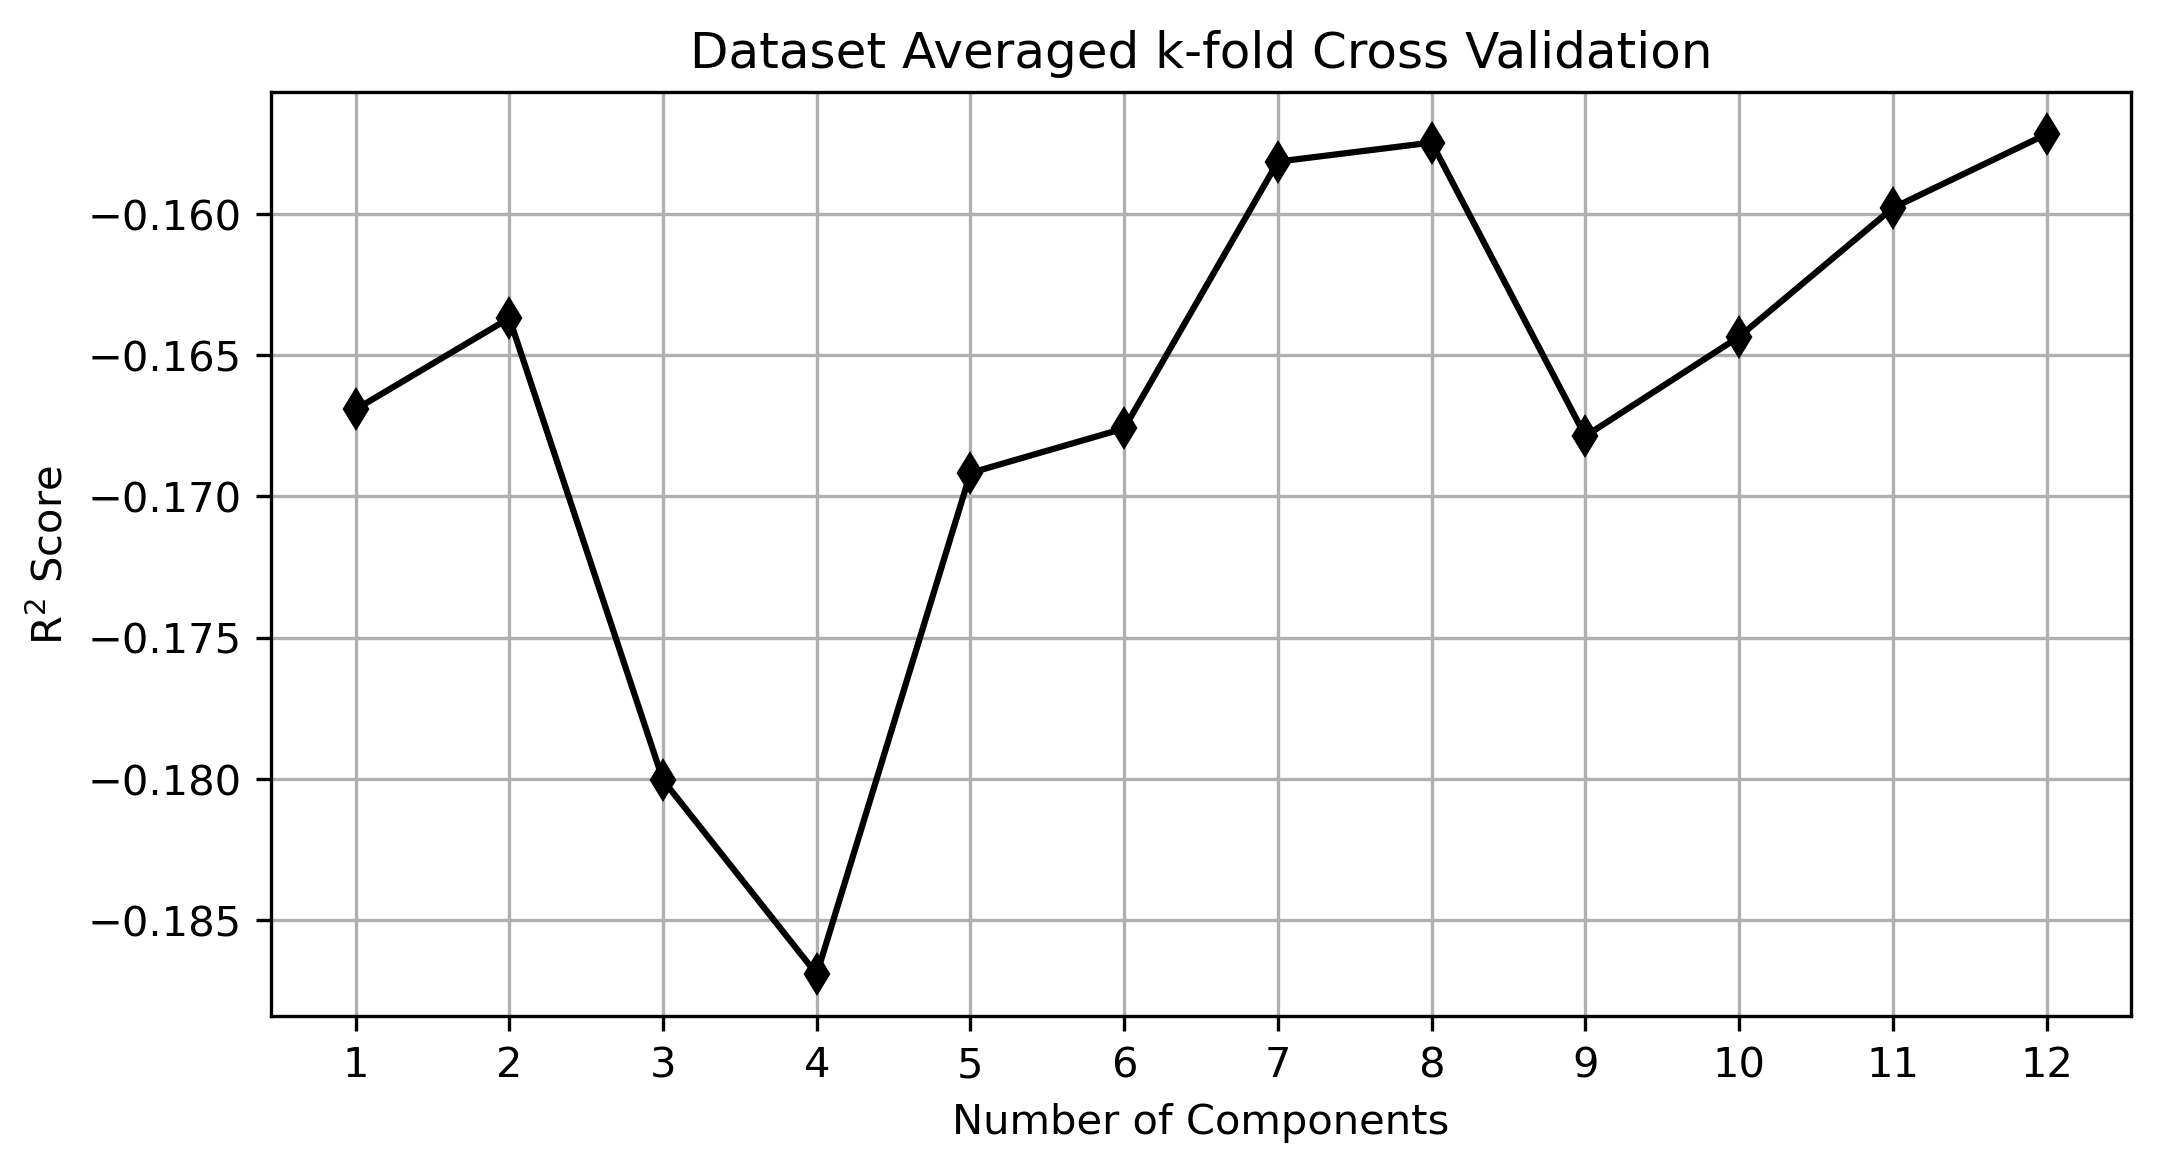

In [10]:
# Plot total variance explained vs. number of components
plt.figure(figsize=(8, 5))
# plt.plot(range(1, max_components + 1), variance_explained * 100, marker='o', linestyle='-')
plt.xlabel("Number of Components")
plt.ylabel("Total Explained Variance (%)")
plt.title("Leave 'p' out Cross-Validation for Optimal Component Selection")
plt.grid(True)
plt.show()

## Pointwise regression

#### Methodology

1. Start with the anomaly spring-mean SAT data (time x lat x lon). Take cosine-latitude-weighted area-average: Y = Area-averaged SAT time-series. High pass filter Y to prevent fitting trends in the two fields.

2. Correlate Y with the SLP predictors z ((time, lat, lon), 20N and poleward) to form a one-point cross-correlation (CC) to serve as the weighting function w.

3. Now take the standardized, column (mean)-centered predictor SLP field X, cosine-latitude-weighted. Standardized X ensures the predictors are weighted by in accordance with their correlation with the predictand. This prevents predictors with large variances and low correlations from influencing the linear combinations.

4. Project onto the CC pattern to obtain a time-varying (time-series) index of the pattern (a PLS predictor z).

5. Now regress zout the predictor field X and the "unfiltered" predictand Y. This creates a set of residual variables that are now the basis for determining the next PLS predictor (if pursuing more than one).

6. To prevent overfitting, you only want to use a limited number of PLS predictors, determined through cross-validation. This is cumbersome for point-wise PLS regression because the optimal number of predictors varies from grid point to grid point.

In [44]:
# Define number of SLP predictors
num_predictors = int(input("Number of SLP Predictors:"))

# Arrays to save induced and residual components for uncertainty
SAT_induced_all, SAT_residual_all, SAT_residual_ds = [], [], []

# Arrays to save all regression plots and overall variance explained
regr_maps, SAT_regr_maps, variance_explained, total_variance_explained = [], [], [], []

# Perform dynamic adjustment for each SAT-SLP dataset combination and average
for sat_idx in range(SAT_anoms_std.shape[0]):  # Loop over SAT datasets
    print('Working on', SAT_names[sat_idx])
    Y = SAT_ts_std[sat_idx, :, 1].copy()  # April
    SAT_ts = SAT_arctic_ts[sat_idx, :, 1].copy()  # April

    # Arrays for SAT dataset averages
    SAT_induced_one, SAT_residual_one = [], []

    for slp_idx in range(SLP_anoms_std.shape[0]):  # Loop over SLP datasets
        print(' > Working on', SLP_names[slp_idx])
        X = np.nanmean(SLP_anoms_std[slp_idx, :, :2].copy(), axis=1)  # March and April

        # Perform dynamic adjustment
        Zs, CC_maps = [], []
        for n in range(num_predictors):
            X, Y, Z, CC = dynamic_adjustment(X, Y, weights=SLP_weights)
            Zs.append(Z)
            CC_maps.append(CC)

        # Regress Z out of the "unfiltered" predictand (dynamically induced)
        SAT_regr = LinearRegression().fit(np.transpose(Zs), SAT_ts)
        SAT_induced = SAT_regr.predict(np.transpose(Zs))
        SAT_induced_one.append(SAT_induced)
        SAT_induced_all.append(SAT_induced)

        # Adjust SAT timeseries by removing the induced component
        SAT_residual = SAT_ts - SAT_induced
        SAT_residual_one.append(SAT_residual)
        SAT_residual_all.append(SAT_residual)

        # Find explained variance from each SLP predictor
        for i in range(len(Zs)):
            if i == 0:
                target = SAT_ts

            # Find explained variance
            r2 = np.square(stats.pearsonr(Zs[i], target)[0])
            variance_explained.append(r2*100)

            # Remove from target to update
            regr = stats.linregress(Zs[i], target)
            recr = regr[1] + regr[0] * Zs[i]
            target = target - recr

            # Find total explained variance
            partial_regr = LinearRegression().fit(np.transpose(Zs[:(i+1)]), SAT_ts)
            partial_regressed = partial_regr.predict(np.transpose(Zs[:(i+1)]))
            r2_tot = np.square(stats.pearsonr(partial_regressed, SAT_ts)[0])
            total_variance_explained.append(r2_tot*100)

            # Print variance
            print('      Component '+str(i+1)+': '+str(r2*100)[:4]+'% of residual variance | Total: '+str(r2_tot*100)[:4]+'%')

        # Standardize the entire Z timeseries
        Zs_std = np.divide(Zs, np.nanstd(Zs, axis=1)[:, np.newaxis])

        # Get the regression maps
        for i, predictor in enumerate(Zs_std):
            if i == 0:
                SLP_map = np.nanmean(SLP_anoms_spring_20N[slp_idx, :, :2], axis=1)  # March and April
            regr_map, SLP_variability_regressed_out = reg_finder(SLP_map, predictor)
            SLP_map = np.swapaxes(SLP_variability_regressed_out, 1, 2)
            regr_maps.append(regr_map)

    # Compute SAT dataset averages
    SAT_residual_ds.append(np.nanmean(SAT_residual_one, axis=0))

# Compute the average of all combinations
SAT_residual_average = np.nanmean(SAT_residual_ds, axis=0)

print('Done!')

Number of SLP Predictors: 3


Working on NOAAv6
 > Working on ERA5
(73, 28, 144) (73,)
      Component 1: 23.9% of residual variance | Total: 23.9%
      Component 2: 21.4% of residual variance | Total: 40.2%
      Component 3: 12.2% of residual variance | Total: 47.5%
Working on HadCRUTv5
 > Working on ERA5
(73, 28, 144) (73,)
      Component 1: 26.3% of residual variance | Total: 26.3%
      Component 2: 24.4% of residual variance | Total: 44.3%
      Component 3: 12.0% of residual variance | Total: 51.1%
Working on GISTv4
 > Working on ERA5
(73, 28, 144) (73,)
      Component 1: 26.7% of residual variance | Total: 26.7%
      Component 2: 24.7% of residual variance | Total: 44.8%
      Component 3: 11.0% of residual variance | Total: 50.9%
Working on BerkeleyEarth
 > Working on ERA5
(73, 28, 144) (73,)
      Component 1: 24.1% of residual variance | Total: 24.1%
      Component 2: 22.8% of residual variance | Total: 41.4%
      Component 3: 11.8% of residual variance | Total: 48.3%
Done!


In [45]:
# For plot...
time = np.arange(1980, 2023, 1)

# Convert lists to arrays
SAT_induced_all = np.reshape(np.concatenate(SAT_induced_all, axis=0), (4, 73))
SAT_residual_all = np.reshape(np.concatenate(SAT_residual_all, axis=0), (4, 73))

# Calculate mean timseries
mean_ts = np.nanmean(SAT_arctic_ts[:, :, 1], axis=0)  # April
mean_ts_ext = np.nanmean(SAT_arctic_ts[:, :, 1], axis=0)  # April

# Calculate the time-averaged standard deviation
# Step 1: Compute standard deviation across datasets at each time step
ind_std = np.std(SAT_induced_all, axis=0)
res_std = np.std(SAT_residual_all, axis=0)

# Step 2: Compute standard error of the mean (SEM) for each time step
N = np.shape(SAT_induced_all)[0]
ind_std_t = ind_std / np.sqrt(N)
res_std_t = res_std / np.sqrt(N)

# Step 3: Compute the average SEM over all time steps
ind_std_avg = np.nanmean(ind_std_t)
res_std_avg = np.nanmean(res_std_t)

# Step 4: Compute the two-sigma interval
ind_2sig = 2 * ind_std_avg
res_2sig = 2 * res_std_avg
tot_2sig = 2 * np.sqrt(ind_std_avg**2 + res_std_avg**2)

# Get multidecadal trends for 1980-2022
tot = stats.linregress(time/10, mean_ts[30:])[0]
res = stats.linregress(time/10, SAT_residual_average[30:])[0]
ind = tot - res

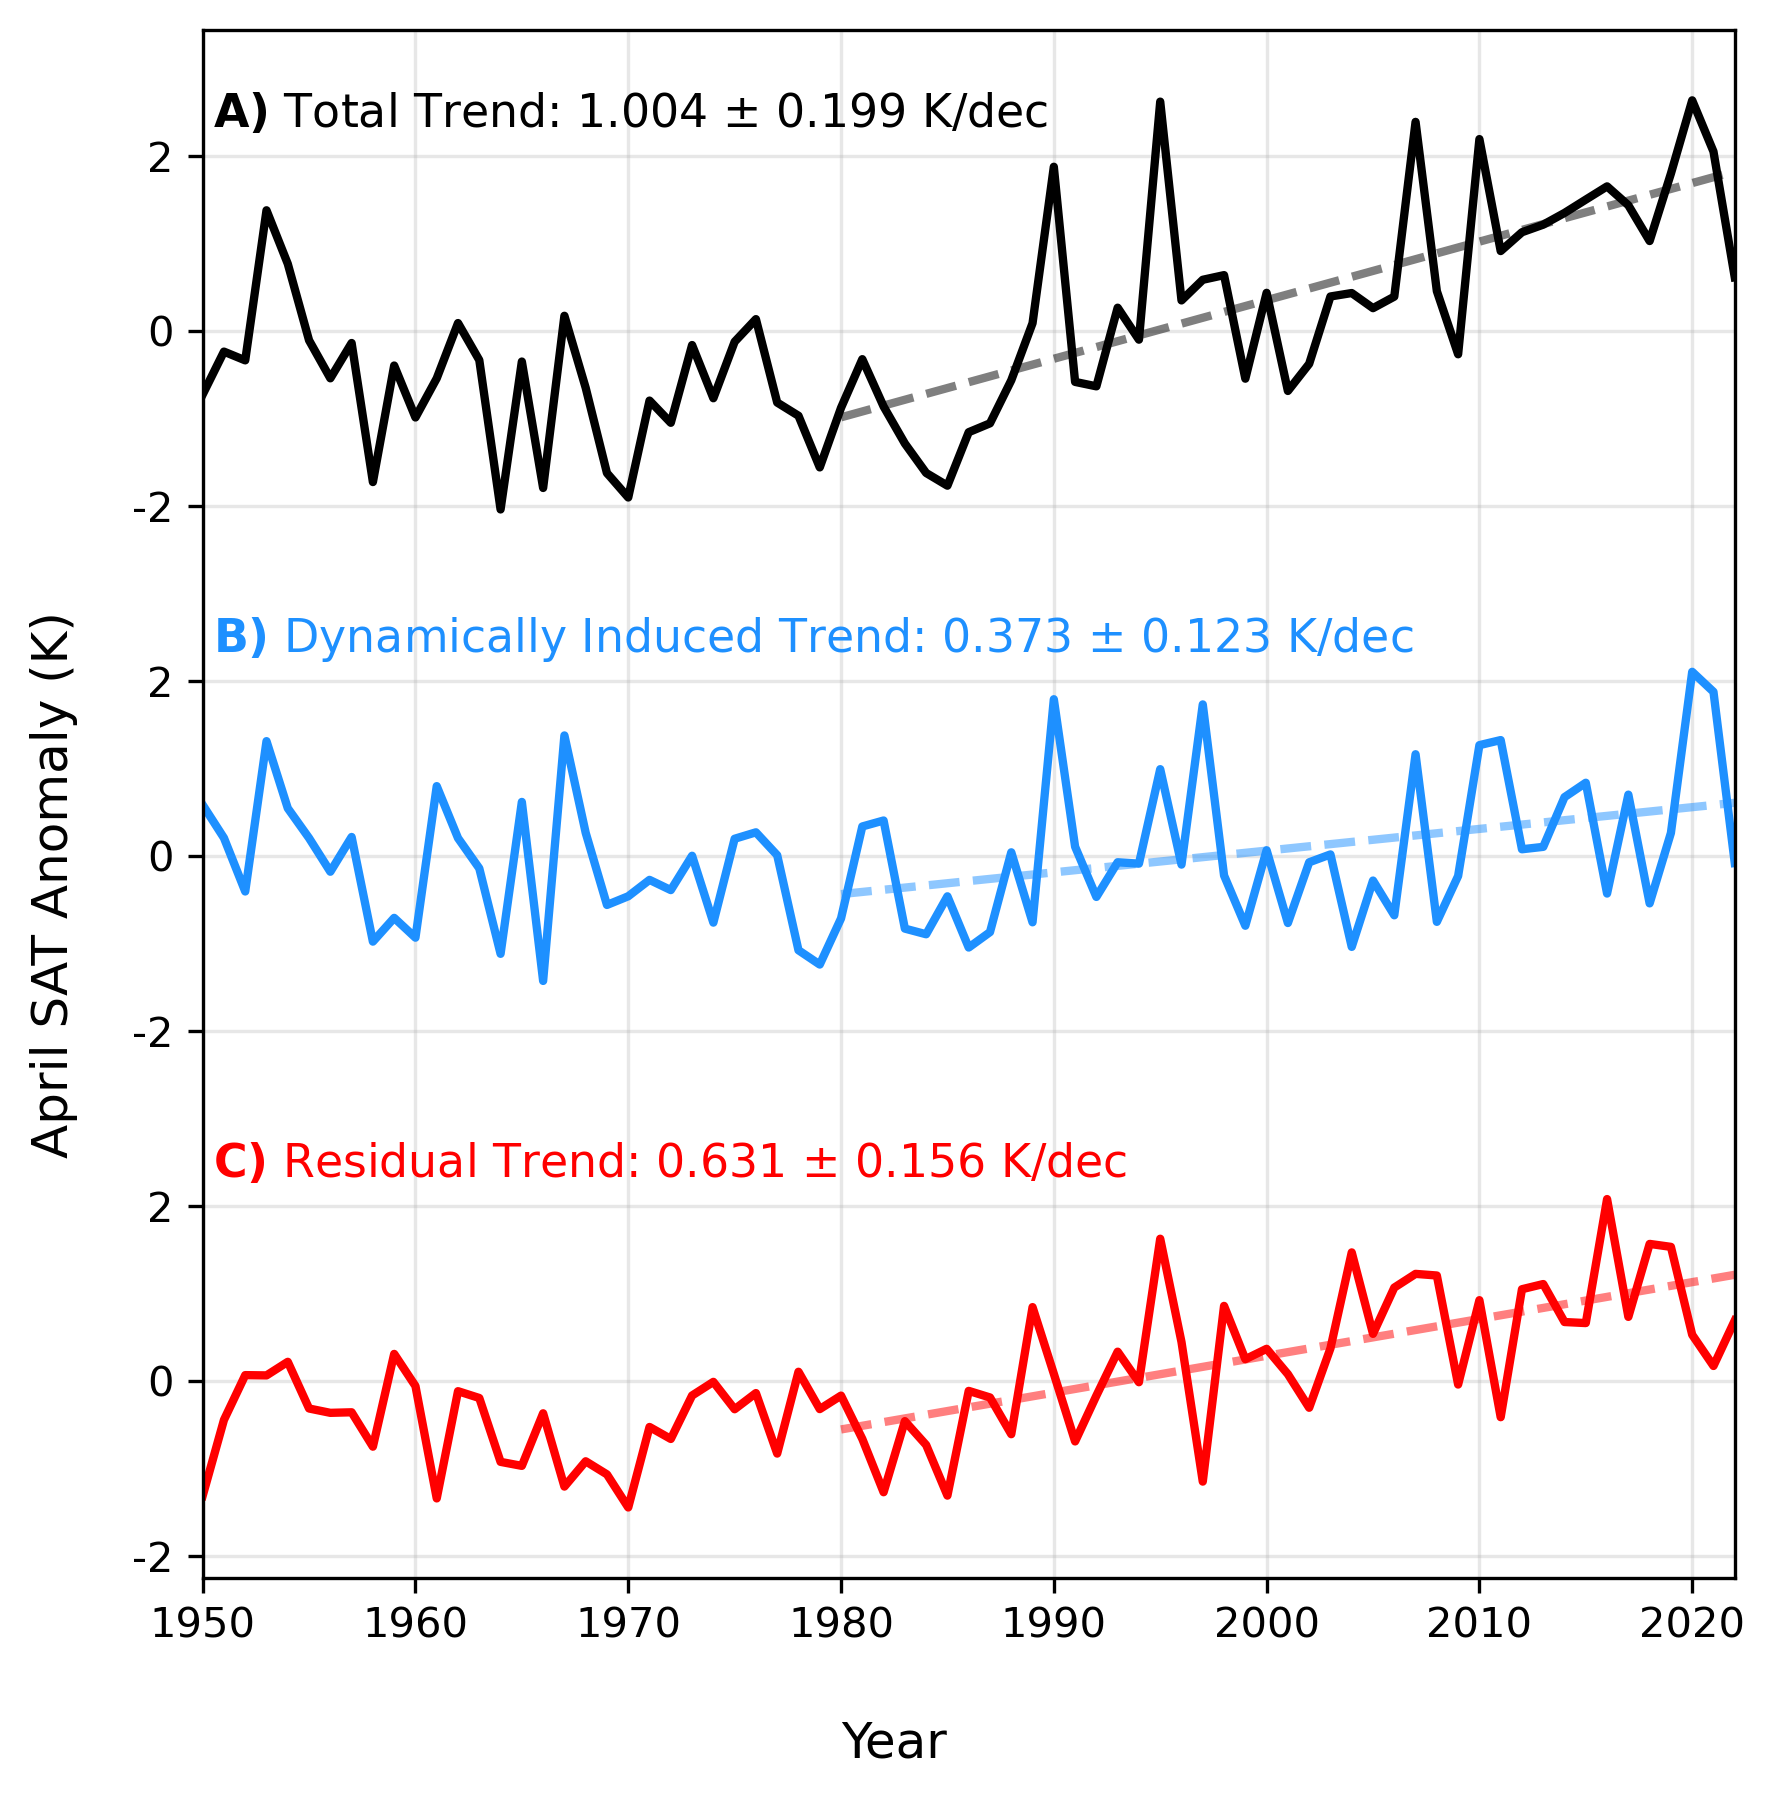

In [46]:
# Create plot
fig, ax = plt.subplots(figsize=(6, 6), dpi=300)

# Plot components with trends
ax.plot(years, mean_ts_ext+18, color='k', lw=2)
line = np.polyfit(time, mean_ts[30:], deg=1)
ax.plot(time, np.polyval(line, time)+18, color='k', alpha=0.5, lw=2, linestyle='--')

ax.plot(years, mean_ts_ext-SAT_residual_average+9, color='dodgerblue', lw=2)
line = np.polyfit(time, mean_ts[30:] - SAT_residual_average[30:], deg=1)
ax.plot(time, np.polyval(line, time)+9, color='dodgerblue', alpha=0.5, lw=2, linestyle='--')

ax.plot(years, SAT_residual_average, color='red', lw=2)
line = np.polyfit(time, SAT_residual_average[30:], deg=1)
ax.plot(time, np.polyval(line, time), color='red', alpha=0.5, lw=2, linestyle='--')

# Trend text labels
label_A, label_B, label_C = "A", "B", "C"
ax.text(1950.5, 21.5, r"$\bf{"+str(label_A)+")}$"+f' Total Trend: {tot:.3f} ± {tot_2sig:.3f} K/dec', color='k', fontsize=11, transform=ax.transData)
ax.text(1950.5, 12.5, r"$\bf{"+str(label_B)+")}$"+f' Dynamically Induced Trend: {ind:.3f} ± {ind_2sig:.3f} K/dec', color='dodgerblue', fontsize=11, transform=ax.transData)
ax.text(1950.5, 3.5, r"$\bf{"+str(label_C)+")}$"+f' Residual Trend: {res:.3f} ± {res_2sig:.3f} K/dec', color='red', fontsize=11, transform=ax.transData)

# Plot customizations
ax.grid(alpha=0.3)
ax.set_xlim(1950, 2022)

# Repeating y-axis
ax.set_yticks([-3, 0, 3, 6, 9, 12, 15, 18, 21])
ax.set_yticklabels(["-2", "0", "2", "-2", "0", "2", "-2", "0", "2"])

# Labels
fig.supxlabel('Year')
fig.supylabel('April SAT Anomaly (K)')

plt.tight_layout()
# plt.savefig(f'./figures/finalv2/monthly/{month_labels[month]}_1980_2022_DynAdj.png', dpi=300, bbox_inches='tight')
plt.show()

In [47]:
# Find mean of each component's regression map
regr_maps_comp = np.reshape(regr_maps, (4, int(num_predictors), 144, 28))
regr_maps_swap = np.swapaxes(regr_maps_comp, 2, 3)
regr_maps_average = np.nanmean(regr_maps_swap, axis=0)
regr_maps_average.shape

(3, 28, 144)

In [48]:
# Variance arrays
var = np.reshape(np.array(variance_explained), (4, int(num_predictors)))
tot_var = np.reshape(np.array(total_variance_explained), (4, int(num_predictors)))

# Convert to float
var = var.astype(float)
tot_var = tot_var.astype(float)

# Get mean by dynamic adjustment
var_mean = np.nanmean(var, axis=0)
tot_mean = np.nanmean(tot_var, axis=0)
var_mean, tot_mean

(array([25.3104328 , 23.35360987, 11.78360065]),
 array([25.3104328 , 42.73732236, 49.49056976]))

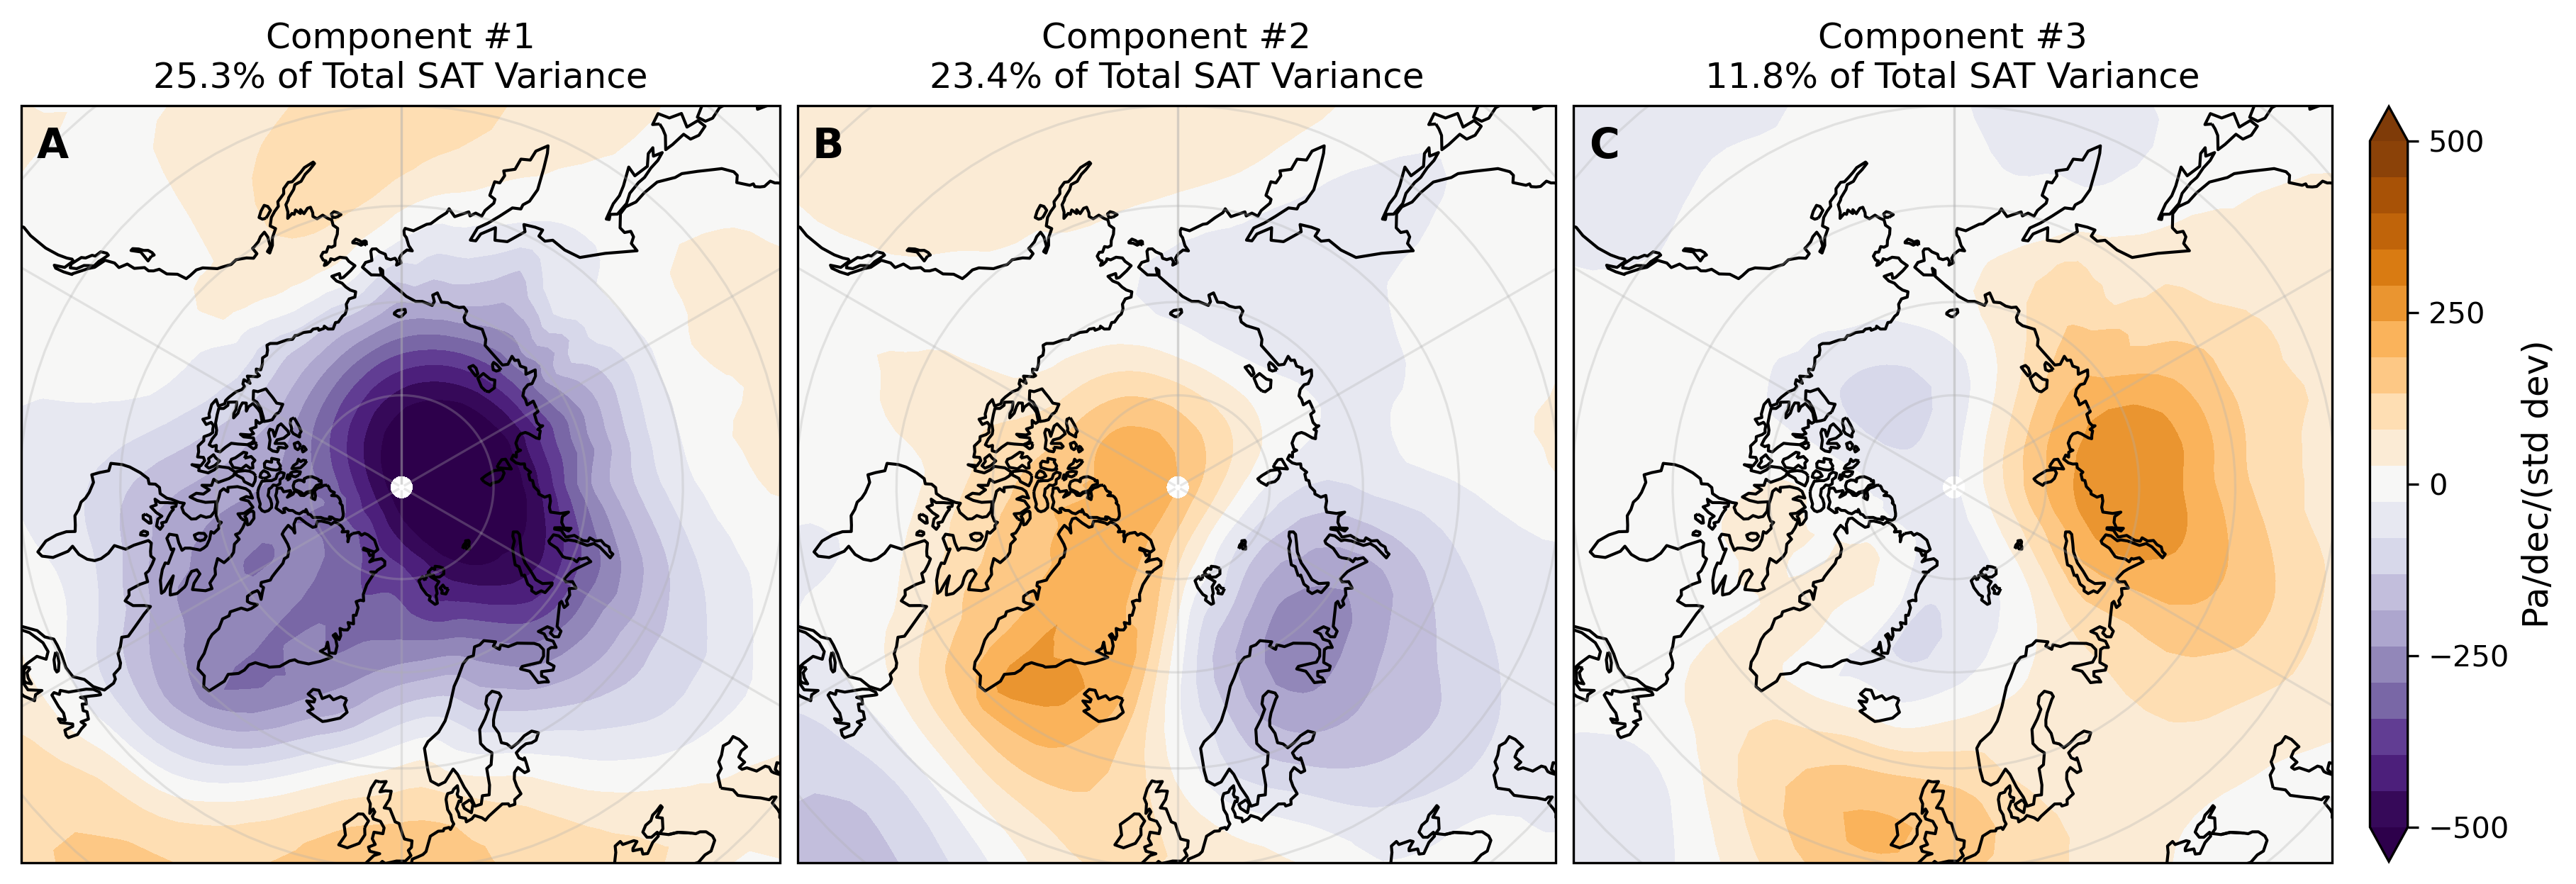

In [49]:
# Plot regression coefficient map
fig, axes = plt.subplots(1, 3, figsize=(12, 6), constrained_layout=True, dpi=300, subplot_kw={'projection': ccrs.NorthPolarStereo()})
axes = axes.ravel()

labels = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L']

for i, axs in enumerate(axes):
    map_cyclic, lon = add_cyclic_point(regr_maps_average[i], coord=lons)

    im = axs.contourf(lon, lats[44:],
                      map_cyclic,
                      cmap='PuOr_r',
                      extend='both',
                      levels=np.linspace(-500, 500, 20),
                      transform=ccrs.PlateCarree())

    axs.set_extent([-180, 180, 50, 90], ccrs.PlateCarree())
    axs.set_title(f'Component #{i+1}\n{var_mean[i]:.1f}% of Total SAT Variance', fontsize=12)
    axs.text(0.02, 0.93, labels[i], transform=axs.transAxes, fontsize=14, fontweight='bold')
    axs.gridlines(alpha=0.3)
    axs.coastlines()

cbar = plt.colorbar(im, ax=axes[2], location='right', shrink=0.6, aspect=20, ticks=np.linspace(-500, 500, 5))
cbar.set_label('Pa/dec/(std dev)', fontsize=12)

# plt.savefig(f'./figures/finalv2/monthly/{month_labels[month]}_SLP_Regressed.png', dpi=300, bbox_inches='tight')
plt.show()

### Component and Observation Comparison

In [60]:
# Get SLP observations
paths = glob.glob('/glade/work/skygale/training-data/monthly/observations/slp/*')

obs_globe_spatial_trends = []
for path in paths:
    ds = xr.open_dataset(path).DATA[month+2]
    obs_globe_spatial_trends.append(ds)

# Calculate mean spatial pressure trends
OBS_globe_spatial_trends = np.nanmean(obs_globe_spatial_trends, axis=0)
print(np.shape(OBS_globe_spatial_trends))

(72, 144)


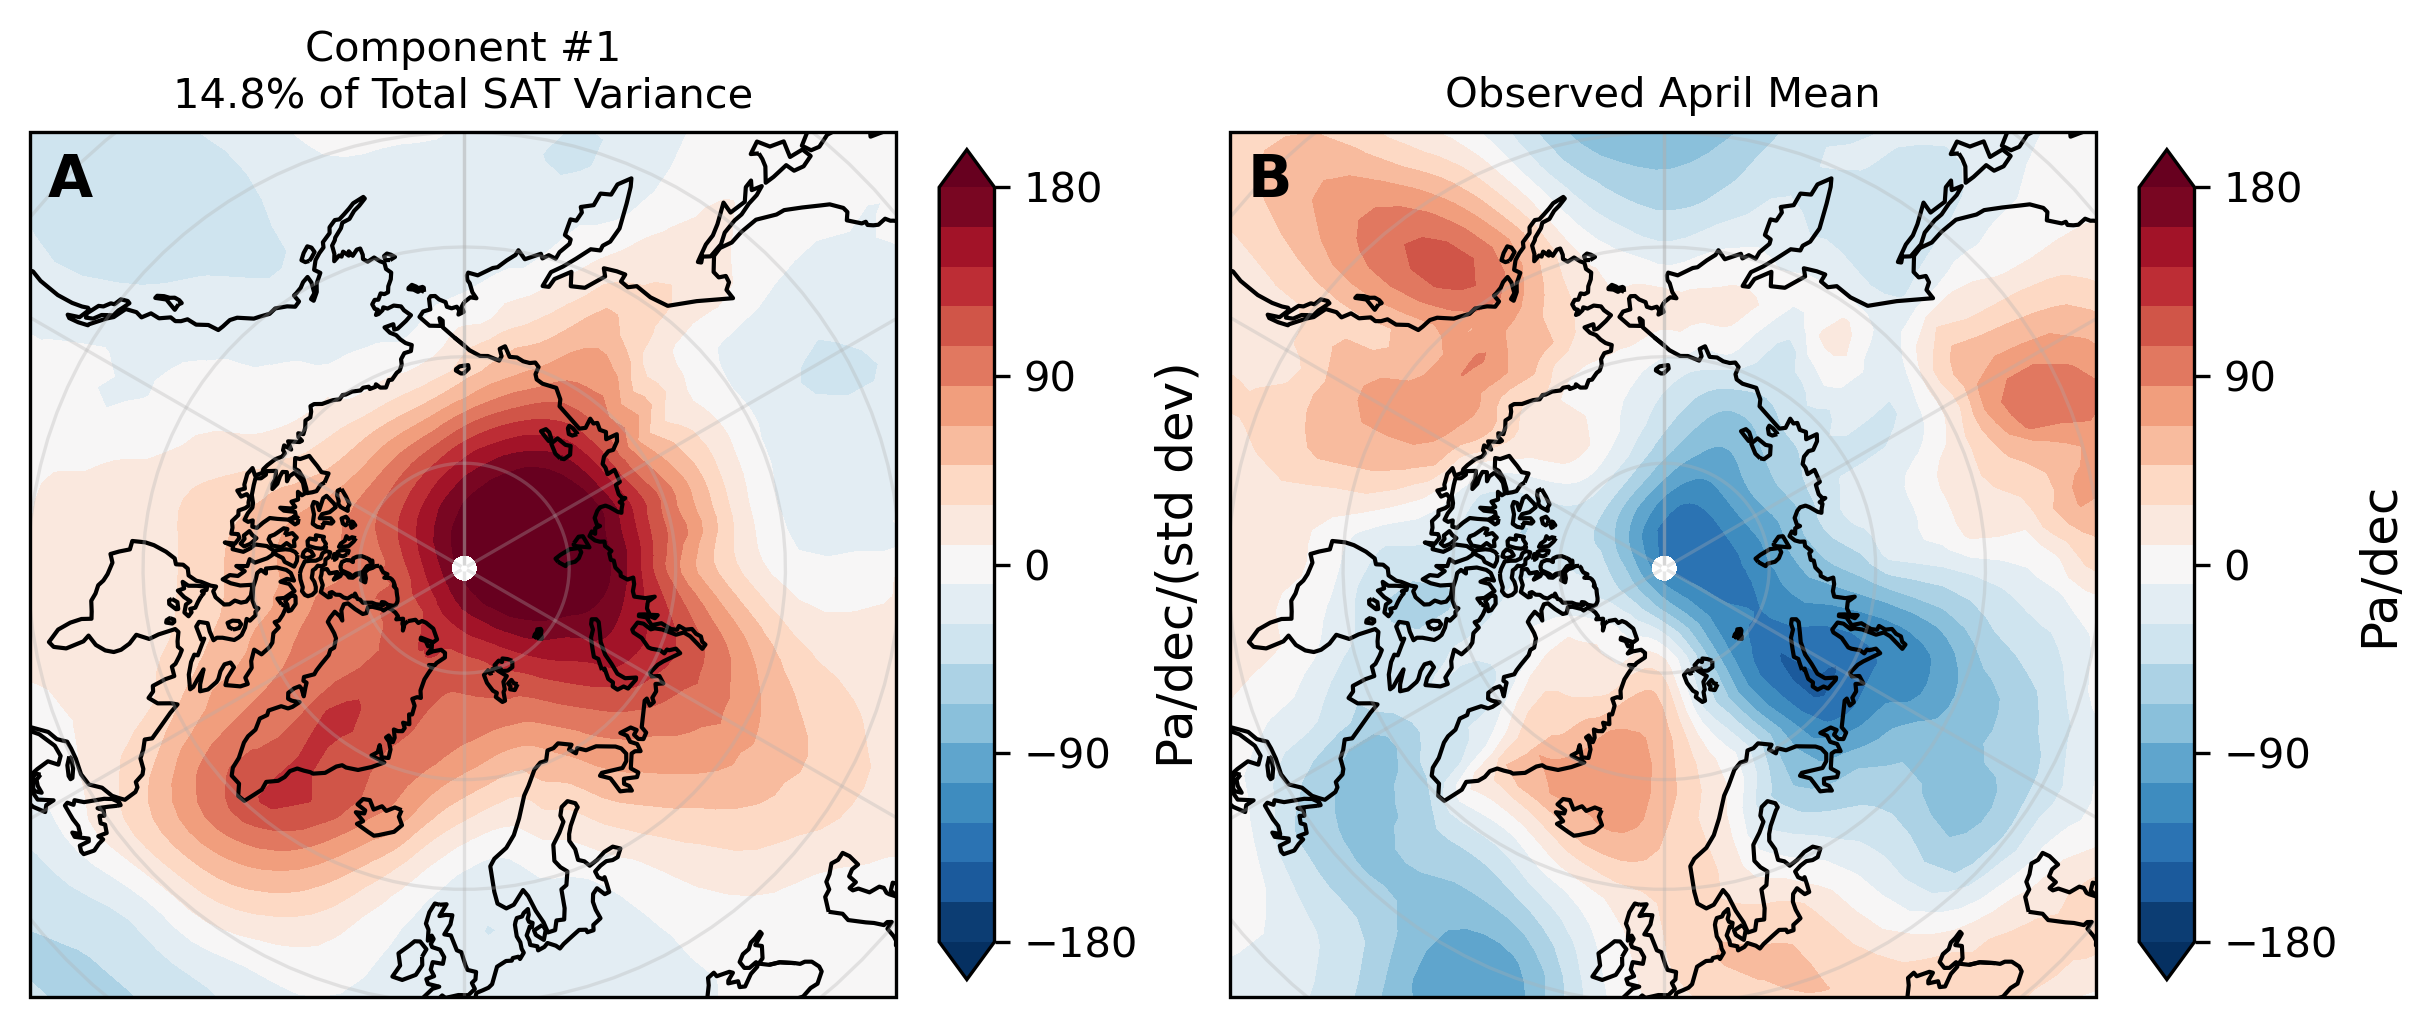

In [61]:
# Plot regression map
fig, axes = plt.subplots(1, 2, figsize=(8, 7), constrained_layout=True, dpi=300, subplot_kw={'projection': ccrs.NorthPolarStereo()})
axes = axes.ravel()

labels = ['A', 'B']
levels = np.linspace(-180, 180, 20)

map_cyclic, lon = add_cyclic_point(regr_maps_average[0], coord=lons)
im1 = axes[0].contourf(lon, lats[44:], map_cyclic,
                       cmap='RdBu_r', extend='both',
                       levels=levels,
                       transform=ccrs.PlateCarree())
axes[0].set_title(f'Component #1\n{var_mean[0]:.1f}% of Total SAT Variance', fontsize=10)

cbar = plt.colorbar(im1, ax=axes[0], location='right', shrink=0.4, aspect=15, ticks=np.linspace(-180, 180, 5))
cbar.set_label('Pa/dec/(std dev)', fontsize=12)

map_cyclic, lon = add_cyclic_point(OBS_globe_spatial_trends, coord=lons)
im2 = axes[1].contourf(lon, lats, map_cyclic,
                       cmap='RdBu_r', extend='both',
                       levels=levels,
                       transform=ccrs.PlateCarree())
axes[1].set_title(f'Observed {month_labels[month]} Mean', fontsize=10)

cbar = plt.colorbar(im2, ax=axes[1], location='right', shrink=0.4, aspect=15, ticks=np.linspace(-180, 180, 5))
cbar.set_label('Pa/dec', fontsize=12)

for i, axs in enumerate(axes):
    axs.set_extent([-180, 180, 50, 90], ccrs.PlateCarree())
    axs.text(0.02, 0.925, labels[i], transform=axs.transAxes, fontsize=14, fontweight='bold')
    axs.gridlines(alpha=0.3)
    axs.coastlines()

plt.savefig(f'./figures/finalv2/monthly/{month_labels[month]}_Comp1_Obs_Comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [46]:
# SLP regressed onto monthly mean SAT
# SAT_anoms_spring_20N: (4, 43, 3, 28, 144)
# SLP_anoms_spring_20N: (3, 43, 3, 28, 144)

month = 2

SLP_SAT_regr_maps = []
for sat_idx in range(np.shape(SAT_anoms_spring_20N)[0]):
    for slp_idx in range(np.shape(SLP_anoms_spring_20N)[0]):
        SLP_SAT_regr_map, _ = reg_finder(SLP_anoms_spring_20N[slp_idx, :, month], SAT_ts_std[sat_idx, :, month])
        SLP_SAT_regr_maps.append(SLP_SAT_regr_map)

SLP_SAT_regr_maps_swap = np.swapaxes(SLP_SAT_regr_maps, 1, 2)
SLP_SAT_regr_maps_average = np.nanmean(SLP_SAT_regr_maps_swap, axis=0)
SLP_SAT_regr_maps_average.shape

(28, 144)

In [47]:
# Get SLP observations
paths = glob.glob('/glade/work/skygale/training-data/monthly/observations/slp/*')

obs_globe_spatial_trends = []
for path in paths:
    ds = xr.open_dataset(path).DATA[month+2]
    obs_globe_spatial_trends.append(ds)

# Calculate mean spatial pressure trends
OBS_globe_spatial_trends = np.nanmean(obs_globe_spatial_trends, axis=0)
print(np.shape(OBS_globe_spatial_trends))

(72, 144)


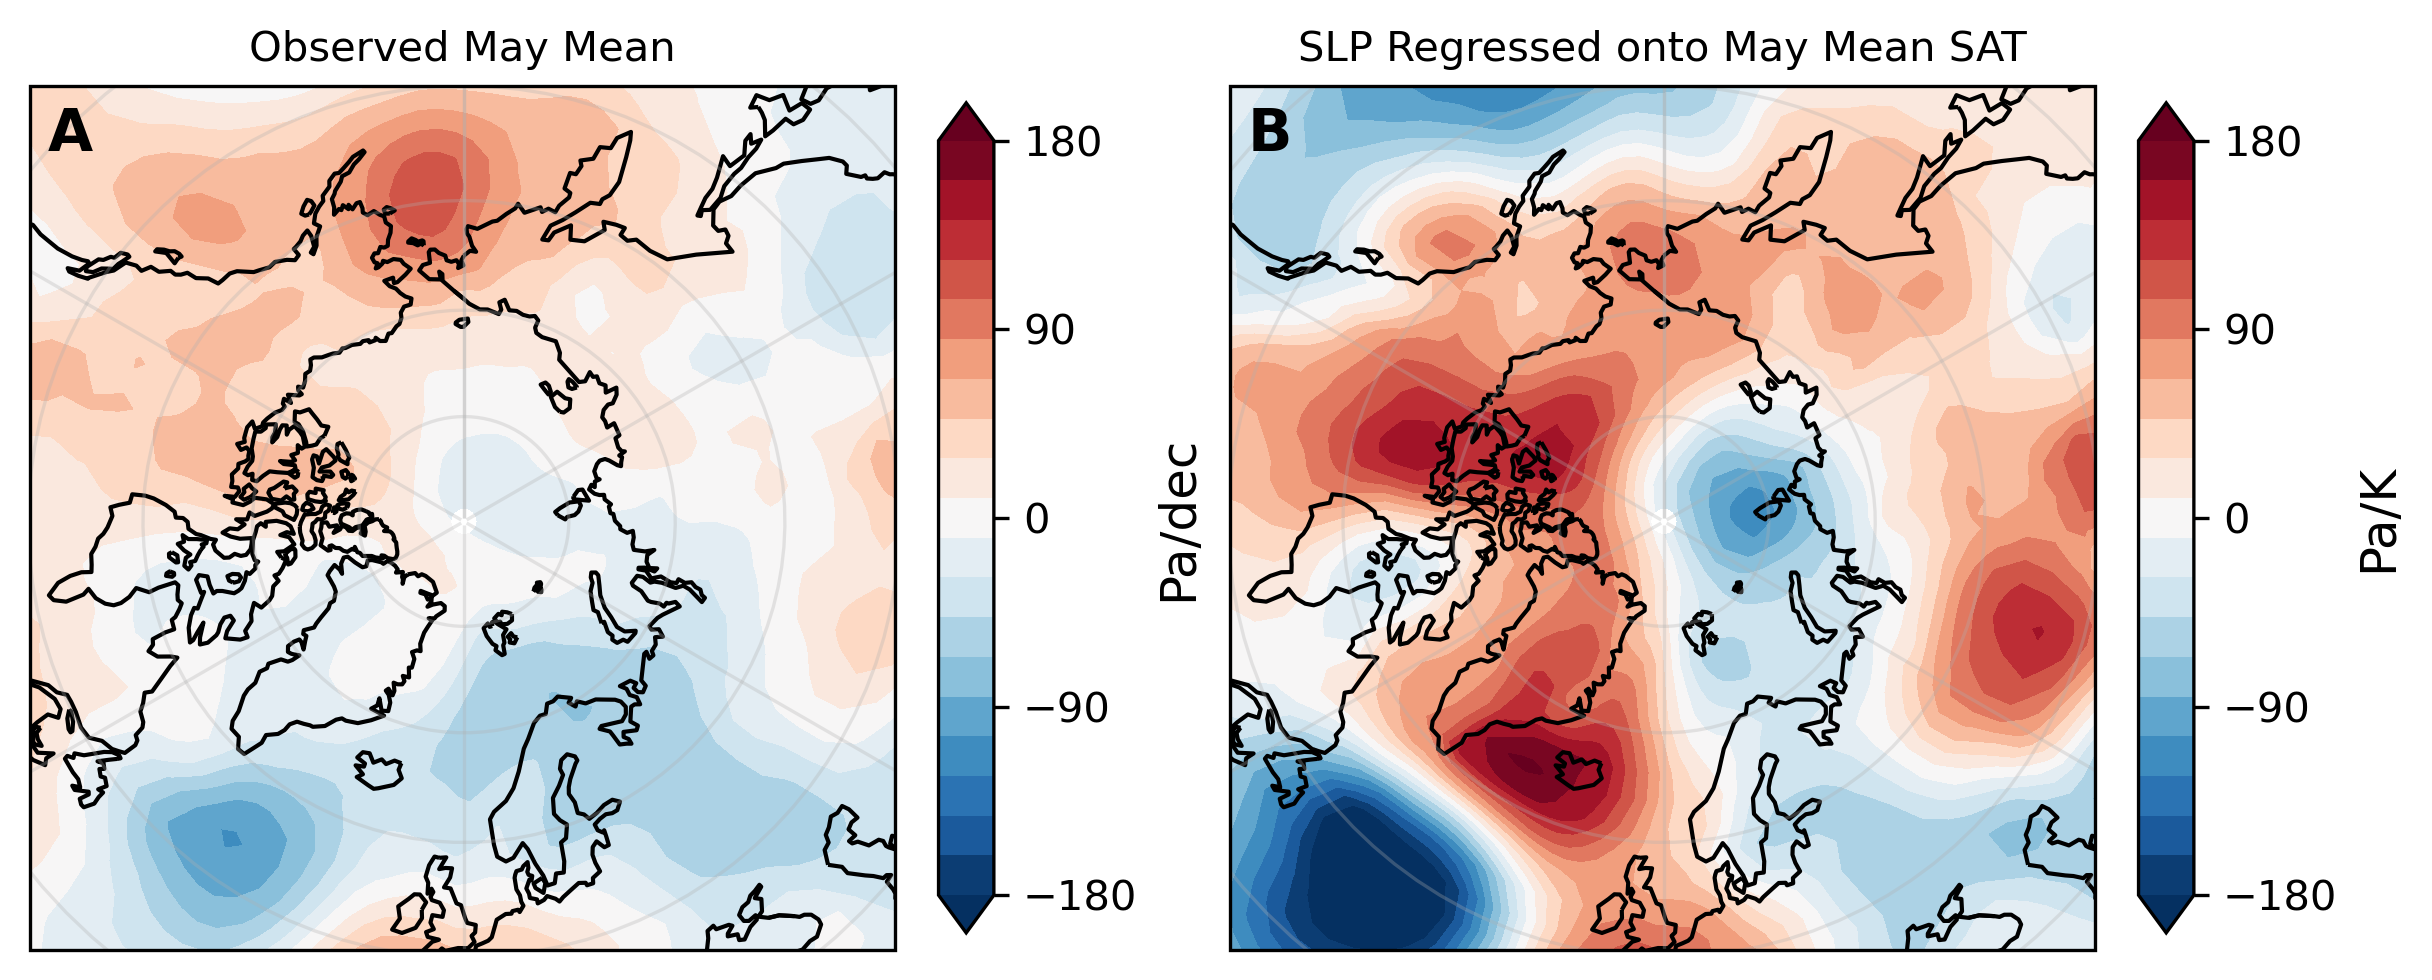

In [48]:
# Plot regression map
fig, axes = plt.subplots(1, 2, figsize=(8, 7), constrained_layout=True, dpi=300, subplot_kw={'projection': ccrs.NorthPolarStereo()})
axes = axes.ravel()
labels = ['A', 'B']

map_cyclic, lon = add_cyclic_point(OBS_globe_spatial_trends, coord=lons)
im1 = axes[0].contourf(lon, lats, map_cyclic,
                       cmap='RdBu_r', extend='both',
                       levels=np.linspace(-180, 180, 20),
                       transform=ccrs.PlateCarree())
axes[0].set_title(f'Observed {month_labels[month]} Mean', fontsize=10)
cbar = plt.colorbar(im1, ax=axes[0], location='right', shrink=0.4, aspect=15, ticks=np.linspace(-180, 180, 5))
cbar.set_label('Pa/dec', fontsize=12)

map_cyclic, lon = add_cyclic_point(SLP_SAT_regr_maps_average, coord=lons)
im2 = axes[1].contourf(lon, lats[44:], map_cyclic,
                       cmap='RdBu_r', extend='both',
                       levels=np.linspace(-180, 180, 20),
                       transform=ccrs.PlateCarree())
axes[1].set_title(f'SLP Regressed onto {month_labels[month]} Mean SAT', fontsize=10)

cbar = plt.colorbar(im2, ax=axes[1], location='right', shrink=0.4, aspect=15, ticks=np.linspace(-180, 180, 5))
cbar.set_label('Pa/K', fontsize=12)

for i, axs in enumerate(axes):
    axs.set_extent([-180, 180, 50, 90], ccrs.PlateCarree())
    axs.text(0.02, 0.925, labels[i], transform=axs.transAxes, fontsize=14, fontweight='bold')
    axs.gridlines(alpha=0.3)
    axs.coastlines()

# plt.savefig(f'./figures/finalv2/monthly/{month_labels[month]}_Comp1_Obs_Comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## PLS regression B

In [ ]:
# Define number of components
# n = int(input("Number of Components:"))

# Perform dynamic adjustment for each SAT-SLP dataset combination and average
# Save arrays for SAT dataset averages and individual combinations
SAT_avg_anoms_spring_ds = []
trend_orig_ds = []
sat_dynamically_induced_ds = []
trend_dynadj_ds = []
sat_dynamically_adjusted_ds = []
trend_residual_ds = []
DynCompPatternMaps_ds = []
DynCompPatternMaps_std_ds = []

SAT_avg_anoms_spring_all = []
trend_orig_all = []
sat_dynamically_induced_all = []
trend_dynadj_all = []
sat_dynamically_adjusted_all = []
trend_residual_all = []
DynCompPatternMaps_all = []
DynCompPatternMaps_std_all = []

name_combo = []

variance_explained = []
total_variance_explained = []

# Loop over all SAT datasets
for sat_idx in range(SAT_np_all.shape[0]):
    print('Working on', SAT_names[sat_idx])
    SAT_np = SAT_np_all[sat_idx]

    # Arrays for each SAT datasets to average
    SAT_avg_anoms_spring_one = []
    trend_orig_one = []
    sat_dynamically_induced_one = []
    trend_dynadj_one = []
    sat_dynamically_adjusted_one = []
    trend_residual_one = []
    DynCompPatternMaps_one = []
    DynCompPatternMaps_std_one = []

    # Loop over all SLP datasets
    for slp_idx in range(SLP_np_all.shape[0]):
        print('  -->', SLP_names[slp_idx])
        SLP_np = SLP_np_all[slp_idx]

        name_combo.append([SAT_names[sat_idx], SLP_names[slp_idx]])

        # Get springtime means
        # --> These are all already anomalies! <--
        SLP_anoms_spring = np.nanmean(SLP_np, axis=1)
        SAT_anoms_spring = np.nanmean(SAT_np, axis=1)

        # Get spring SAT timeseries data
        SAT_anoms_weighted = weighted_spatial(SAT_np[:, :, 20:], lats[20:])
        SAT_avg_anoms_spring = np.nanmean(SAT_anoms_weighted, axis=1)
        SAT_avg_anoms_spring_one.append(SAT_avg_anoms_spring)
        SAT_avg_anoms_spring_all.append(SAT_avg_anoms_spring)

        # Find and plot trends
        # SLP_spr_trend = trend_finder(SLP_anoms_spring)
        # SAT_spr_trend = trend_finder(SAT_anoms_spring)
        # plot_trends(SLP_spr_trend, SAT_spr_trend, SLP_names[slp_idx], SAT_names[sat_idx], sat_idx)

        # Standardize data
        sat_ma_std = SAT_avg_anoms_spring / np.nanstd(SAT_avg_anoms_spring)
        sat_ma_std_map = SAT_anoms_spring / np.nanstd(SAT_anoms_spring, axis=0)
        slp_ma_std = SLP_anoms_spring / np.nanstd(SLP_anoms_spring, axis=0)

        # Perform dynamic adjustment
        X = slp_ma_std.copy()
        Y = sat_ma_std.copy()
        Zs_sat = []

        for k in range(n):
            Z = dynamic_adjustment(X, Y, weights=np.cos(np.deg2rad(lats)), pls_number=k)
            Z[np.isnan(Z)] = 0
            Zs_sat.append(Z)

        # Regress dynamically induced component
        sat_reg = LinearRegression().fit(np.transpose(Zs_sat), SAT_avg_anoms_spring)
        sat_dynamically_induced = sat_reg.predict(np.transpose(Zs_sat))
        sat_dynamically_induced_one.append(sat_dynamically_induced)
        sat_dynamically_induced_all.append(sat_dynamically_induced)

        # Adjust the SAT timeseries by removing the dynamically induced component
        sat_dynamically_adjusted = SAT_avg_anoms_spring - sat_dynamically_induced
        sat_dynamically_adjusted_one.append(sat_dynamically_adjusted)
        sat_dynamically_adjusted_all.append(sat_dynamically_adjusted)

        # Find the explained variance from each component
        for i in range(len(Zs_sat)):
            if i == 0:
                target = SAT_avg_anoms_spring

            # Find explained variance
            r2 = np.square(stats.pearsonr(Zs_sat[i], target)[0])
            print('      Component '+str(i+1)+': '+str(r2*100)[:4]+'% of residual variance')
            variance_explained.append(str(r2*100)[:4])

            # Remove from target
            regr = stats.linregress(Zs_sat[i], target)
            recreation = Zs_sat[i] * regr[0] + regr[1]
            target = target - recreation

            # Find total explained variance
            sat_reg = LinearRegression().fit(np.transpose(Zs_sat[:(i+1)]), SAT_avg_anoms_spring)
            sat_regressed = sat_reg.predict(np.transpose(Zs_sat[:(i+1)]))
            r2_tot = np.square(stats.pearsonr(sat_regressed, SAT_avg_anoms_spring)[0])
            print('      Total variance explained: '+str(r2_tot*100)[:4]+'%')
            total_variance_explained.append(str(r2_tot*100)[:4])

        # Find trends for plots
        trend_orig = stats.linregress(decades, SAT_avg_anoms_spring)[0]
        trend_orig_one.append(trend_orig)
        trend_orig_all.append(trend_orig)
        trend_residual = stats.linregress(decades, sat_dynamically_adjusted)[0]
        trend_residual_one.append(trend_residual)
        trend_residual_all.append(trend_residual)
        trend_dynadj = trend_orig - trend_residual
        trend_dynadj_one.append(trend_dynadj)
        trend_dynadj_all.append(trend_dynadj)

        # Standardize the Z timeseries
        Zs_sat_std = np.divide(Zs_sat, np.nanstd(Zs_sat, axis=1)[:, np.newaxis])

        # Get the standardized pattern maps
        DynCompPatternMaps_std = []
        for idx, DynComp in enumerate(Zs_sat_std):
            if idx == 0:
                SLP_map = slp_ma_std
            regression_map_std, SLP_variability_regressed_out = reg_finder(SLP_map, DynComp)
            SLP_map = np.swapaxes(SLP_variability_regressed_out, 1, 2)
            DynCompPatternMaps_std.append(regression_map_std)
        DynCompPatternMaps_std_one.append(DynCompPatternMaps_std[0])
        DynCompPatternMaps_std_all.append(DynCompPatternMaps_std[0])

        # Get the pattern maps
        DynCompPatternMaps = []
        for idx, DynComp in enumerate(Zs_sat):
            if idx == 0:
                SLP_map = slp_ma_std
            regression_map, SLP_variability_regressed_out = reg_finder(SLP_map, DynComp)
            DynCompPatternMaps.append(regression_map)
        DynCompPatternMaps_one.append(DynCompPatternMaps[0])
        DynCompPatternMaps_all.append(DynCompPatternMaps[0])

    # Compute SAT dataset averages
    SAT_avg_anoms_spring_ds.append(np.nanmean(SAT_avg_anoms_spring_one, axis=0))
    trend_orig_ds.append(np.nanmean(trend_orig_one, axis=0))
    sat_dynamically_induced_ds.append(np.nanmean(sat_dynamically_induced_one, axis=0))
    trend_dynadj_ds.append(np.nanmean(trend_dynadj_one, axis=0))
    sat_dynamically_adjusted_ds.append(np.nanmean(sat_dynamically_adjusted_one, axis=0))
    trend_residual_ds.append(np.nanmean(trend_residual_one, axis=0))
    DynCompPatternMaps_ds.append(np.nanmean(DynCompPatternMaps_one, axis=0))
    DynCompPatternMaps_std_ds.append(np.nanmean(DynCompPatternMaps_std_one, axis=0))

# Compute the average of all combinations
SAT_avg_anoms_spring_average = np.nanmean(SAT_avg_anoms_spring_ds, axis=0)
trend_orig_average = np.nanmean(trend_orig_ds, axis=0)
SAT_dynamically_induced_average = np.nanmean(sat_dynamically_induced_ds, axis=0)
trend_dynadj_average = np.nanmean(trend_dynadj_ds, axis=0)
SAT_dynamically_adjusted_average = np.nanmean(sat_dynamically_adjusted_ds, axis=0)
trend_residual_average = np.nanmean(trend_residual_ds, axis=0)
DynCompPatternMaps_average = np.nanmean(DynCompPatternMaps_ds, axis=0)
DynCompPatternMaps_std_average = np.nanmean(DynCompPatternMaps_std_ds, axis=0)

# Initialize timeseries figure
plt.figure(figsize=(12, 4), dpi=300)

# Plot data
plt.plot(years, SAT_avg_anoms_spring_average, color='black', label='Arctic Total Trend: '+str(trend_orig_average)[:5]+' K/dec')
plt.plot(years, SAT_dynamically_adjusted_average, color='blue', label='Dynamically Induced Trend: '+str(trend_residual_average)[:5]+' K/dec')
plt.plot(years, SAT_dynamically_induced_average, color='red', label='Residual Trend: '+str(trend_dynadj_average)[:5]+' K/dec')

# Plot lines of best fit
p_total = np.polyfit(years, SAT_avg_anoms_spring_average, deg=1)
plt.plot(years, np.polyval(p_total, years), color='black', alpha=0.5, linestyle='--')
p_res = np.polyfit(years, SAT_dynamically_adjusted_average, deg=1)
plt.plot(years, np.polyval(p_res, years), color='blue', alpha=0.5, linestyle='--')
p_dyn = np.polyfit(years, SAT_dynamically_induced_average, deg=1)
plt.plot(years, np.polyval(p_dyn, years), color='red', alpha=0.5, linestyle='--')

plt.legend(loc='upper left')
plt.xlim(1980, 2022)
plt.xlabel('Year')
plt.ylabel('Surface Air Temperature Anomaly [K]')
plt.title(f"Dataset Mean Dynamical Adjustment, {n} Component(s)")
plt.grid(alpha=0.5)
plt.tight_layout()
plt.savefig(f'./figures/Mean_DynAdj_{n}_Components.png', dpi=300)
plt.show()

# Plot regression maps (not standardized and standardized)
fig, axs = plt.subplots(1, 2, figsize=(10, 6), dpi=300, subplot_kw={'projection': ccrs.NorthPolarStereo()})
axs = axs.ravel()

axs[0].set_extent([-180, 180, 40, 90], ccrs.PlateCarree())
map_cyclic, lon = add_cyclic_point(DynCompPatternMaps_average.T, coord=lons)
im = axs[0].contourf(lon, lats, map_cyclic, cmap='RdBu_r', extend='both',
                     levels=np.linspace(-10, 10, 20),
                     transform=ccrs.PlateCarree())
axs[0].set_title(f'Component #{n}, {str(r2*100)[:2]}% of Residual Variance')
cbar = plt.colorbar(im, ax=axs[0], orientation='vertical', shrink=0.6, ticks=[-10, 0, 10])
cbar.set_label('Pa/dec')
axs[0].gridlines(ls=':', color='grey')
axs[0].coastlines(resolution='50m')

axs[1].set_extent([-180, 180, 40, 90], ccrs.PlateCarree())
map_cyclic, lon = add_cyclic_point(DynCompPatternMaps_std_average.T, coord=lons)
im = axs[1].contourf(lon, lats, map_cyclic, cmap='RdBu_r', extend='both',
                     levels=np.linspace(-1, 1, 20),
                     transform=ccrs.PlateCarree())
axs[1].set_title(f'Component #{n}, {str(r2*100)[:2]}% of Residual Variance')
cbar = plt.colorbar(im, ax=axs[1], orientation='vertical', shrink=0.6, ticks=[-1, 0, 1])
cbar.set_label('Pa/dec (Standardized)')
axs[1].gridlines(ls=':', color='grey')
axs[1].coastlines(resolution='50m')

plt.tight_layout()
plt.savefig(f'./figures/Mean_PatternMap_Component{n}.png', dpi=300)
plt.show()

## Variance Plots

In [20]:
var, var_mean, tot_var, tot_mean

(array([[17.8 ,  7.24, 16.1 ],
        [12.9 ,  0.  ,  6.26],
        [13.1 ,  2.55,  7.09],
        [21.6 , 14.8 , 15.9 ],
        [15.  ,  0.04,  1.6 ],
        [12.4 ,  5.09, 19.6 ],
        [19.  , 15.  , 18.1 ],
        [12.2 ,  0.18,  1.68],
        [10.9 ,  2.7 , 25.  ],
        [20.8 , 16.7 , 14.5 ],
        [14.5 ,  0.69,  1.86],
        [12.1 ,  4.41, 20.2 ]]),
 array([15.19166667,  5.78333333, 12.32416667]),
 array([[17.8, 23.7, 36.1],
        [12.9, 12.9, 18.4],
        [13.1, 15.3, 21.3],
        [21.6, 33.2, 43.9],
        [15. , 15. , 16.4],
        [12.4, 16.9, 33.3],
        [19. , 31.3, 43.7],
        [12.2, 12.4, 13.8],
        [10.9, 13.3, 35. ],
        [20.8, 34.1, 43.6],
        [14.5, 15.1, 16.7],
        [12.1, 15.9, 33. ]]),
 array([15.19166667, 19.925     , 29.6       ]))

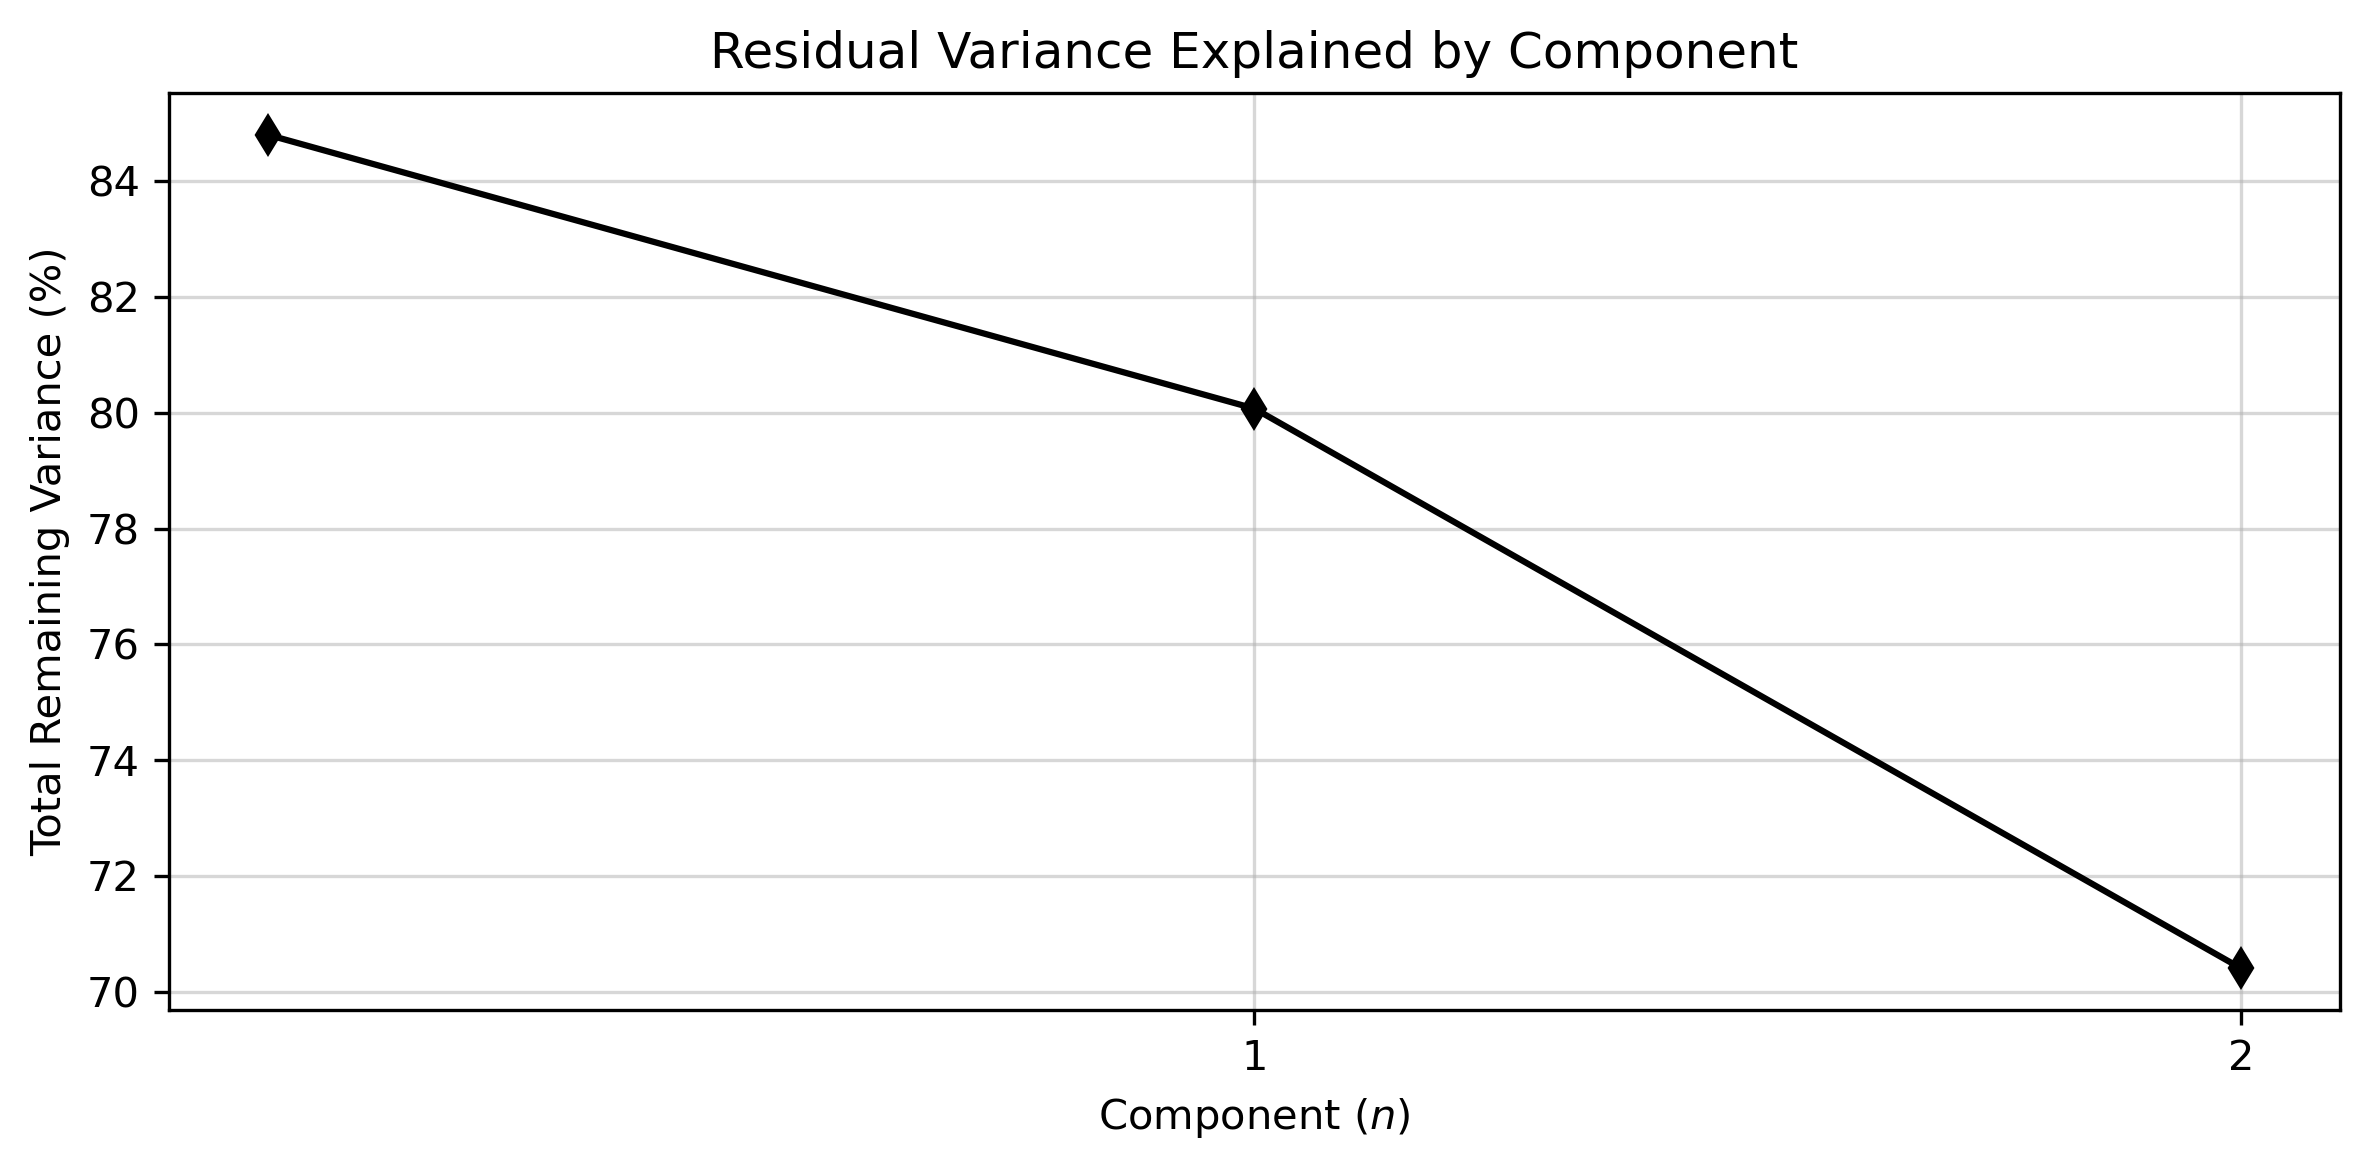

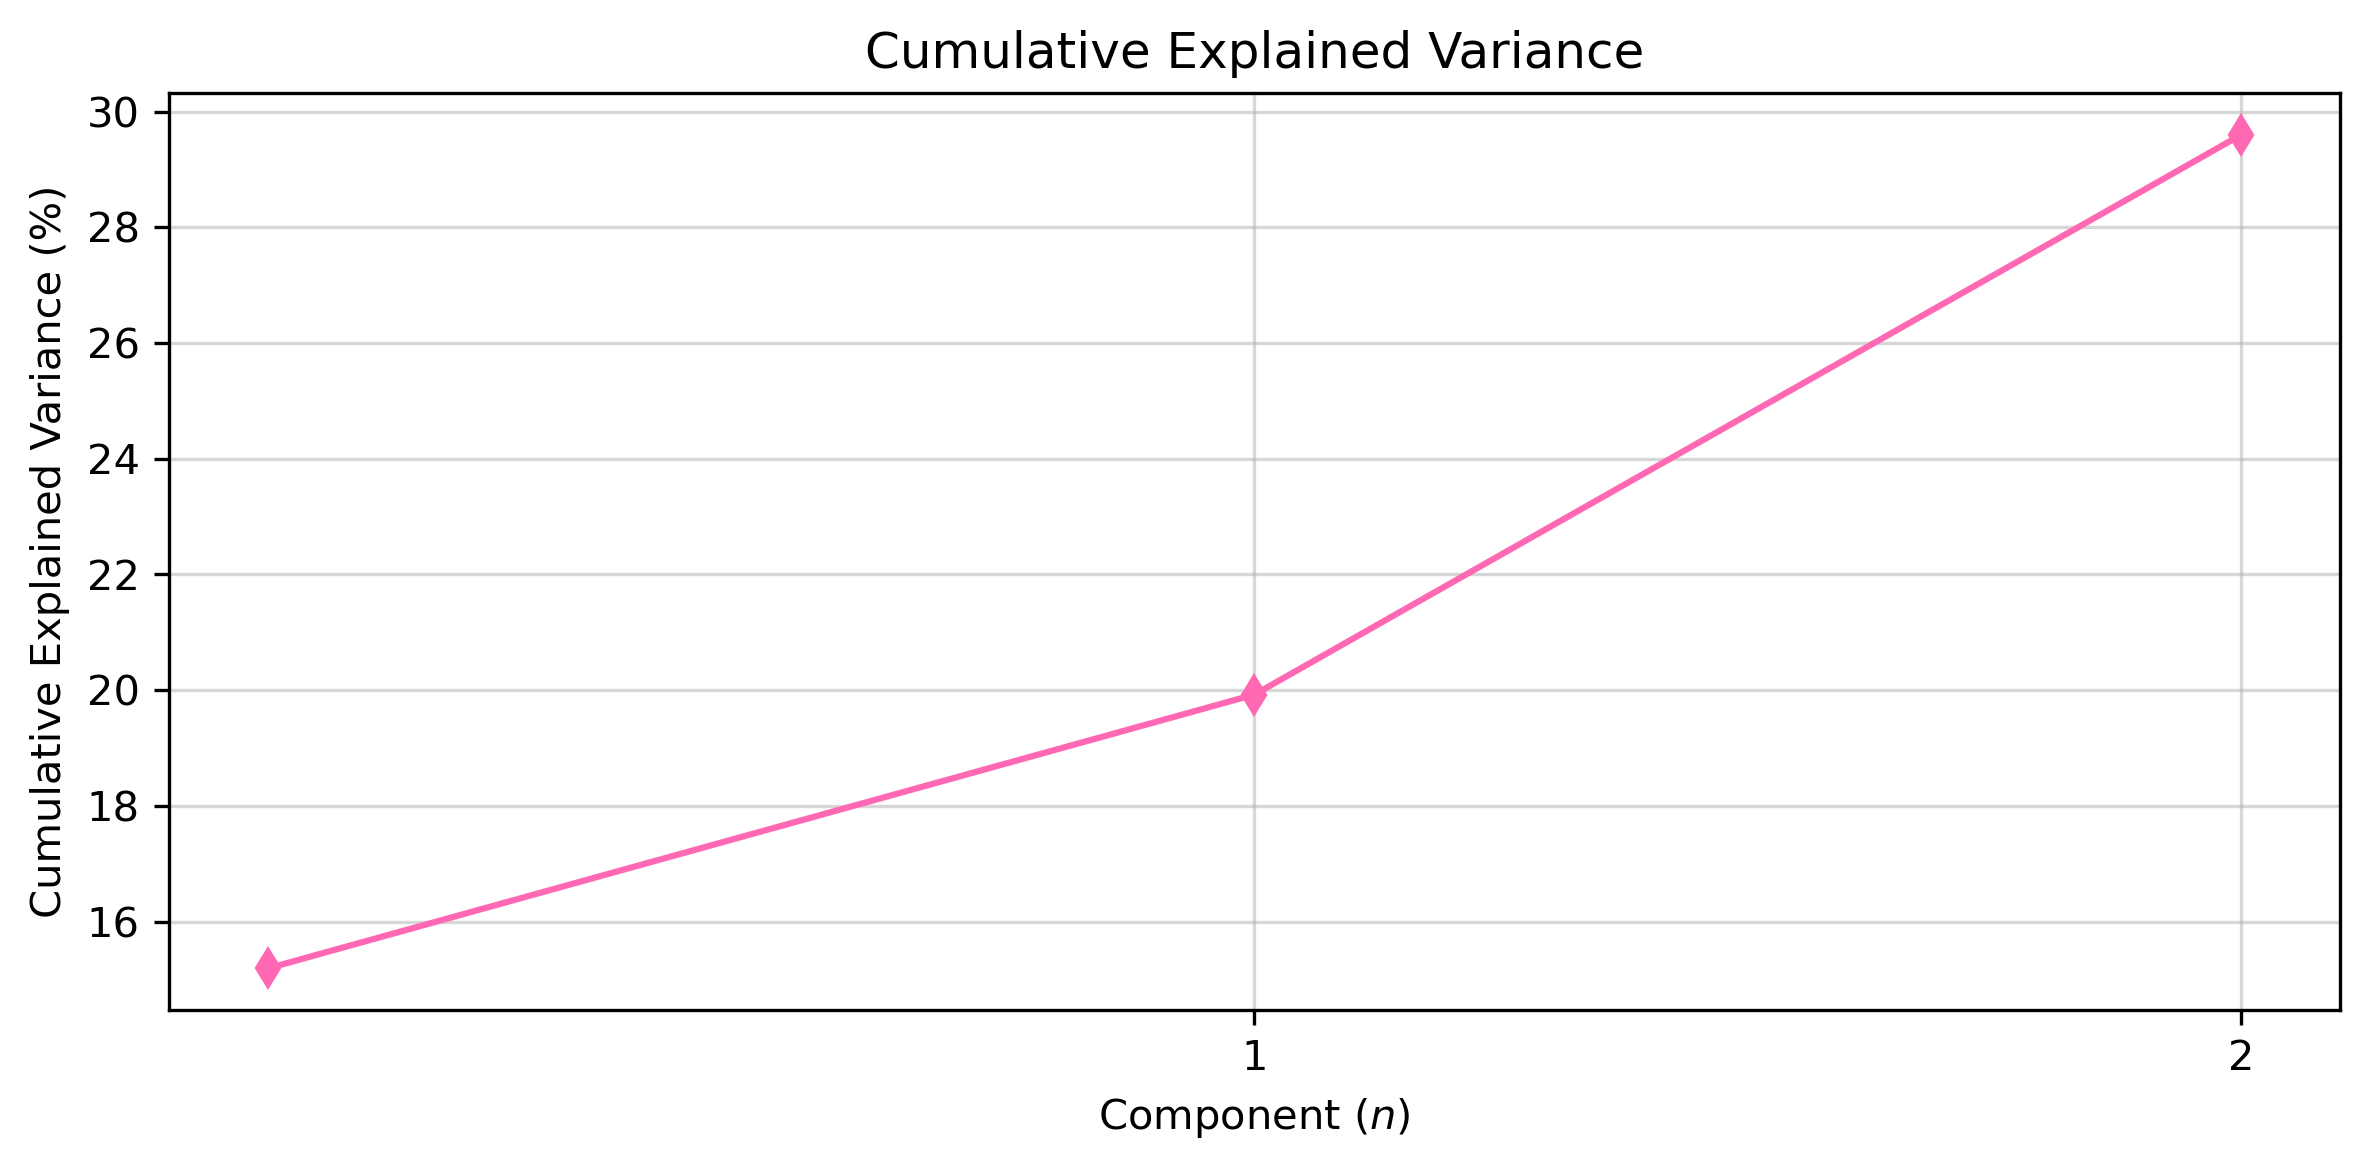

In [21]:
# Explained variance by component
plt.figure(figsize=(8, 4), dpi=300)
plt.plot(np.arange(3), 100 - tot_mean, color='k', marker='d')
plt.xlabel('Component ($n$)')
plt.ylabel('Total Remaining Variance (%)')
plt.title('Residual Variance Explained by Component')
plt.xticks(np.arange(n)+1)
plt.grid(alpha=0.5)
plt.tight_layout()
# plt.savefig('./figures/Residual_Variance_Explained_by_Component.png', dpi=300)
plt.show()

# Cumulative explained variance
plt.figure(figsize=(8, 4), dpi=300)
plt.plot(np.arange(3), tot_mean, color='hotpink', marker='d')
plt.xlabel('Component ($n$)')
plt.ylabel('Cumulative Explained Variance (%)')
plt.title('Cumulative Explained Variance')
plt.xticks(np.arange(n)+1)
plt.grid(alpha=0.5)

'''
# Add thresholds for clarity
thresholds = [70, 80, 90]
for threshold in thresholds:
    component_idx = np.argmax(tot_mean >= threshold) + 1
    plt.axhline(y=threshold, color='hotpink', linestyle='--')
    plt.text(component_idx, threshold + 1, color='black', fontsize=8, ha='left')
'''

plt.tight_layout()
# plt.savefig('./figures/Cumulative_Variance_Explained.png', dpi=300)
plt.show()